Task 2: Credit Risk Prediction

Import Libraries ,load & inspect Use pd.read_csv() to load your file and check the first few rows with .head().

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv('test.csv')
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [6]:
df.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

Simple Imputation (Filling with Mode) For categorical columns like Gender or Credit_History, fill the gaps with the most frequent value (the mode).

In [23]:
# 1. Fill any remaining nulls (Safety check)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# 2. Convert categories to numbers (One-Hot Encoding)
# This handles Gender, Married, Education, etc.
df_final = pd.get_dummies(df.drop('Loan_ID', axis=1), drop_first=True)

df.isnull().sum()


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Exploratory Data Analysis (EDA)                                                                                        Loan Amount Distribution

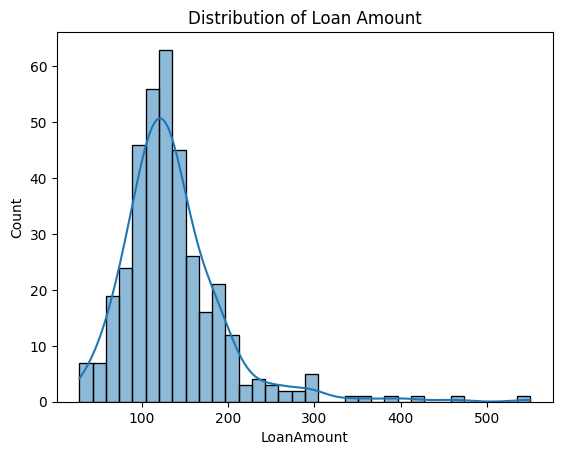

In [15]:
sns.histplot(df['LoanAmount'], kde=True)
plt.title('Distribution of Loan Amount')
plt.show()

Education Impact

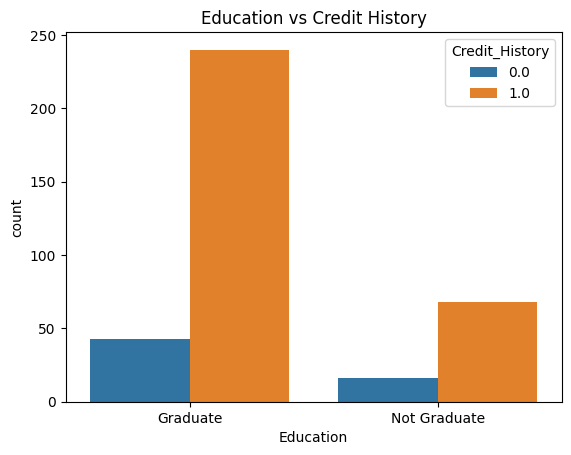

In [16]:
sns.countplot(x='Education', hue='Credit_History', data=df)
plt.title('Education vs Credit History')
plt.show()

Training the Model

In [ ]:
# 1. Load the data [cite: 15]
df = pd.read_csv('train.csv')

# 2. CLEANING: Handle the "3+" and Missing Values [cite: 32]
df['Dependents'] = df['Dependents'].replace('3+', 3)
# You must fill nulls here before the next step
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# 3. ENCODING: Convert text to numbers [cite: 51]
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
df_model = pd.get_dummies(df.drop('Loan_ID', axis=1), drop_first=True)

# 4. SPLITTING: Define X and y 
X = df_model.drop('Loan_Status', axis=1)
y = df_model['Loan_Status']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. TRAINING & EVALUATION [cite: 34, 35]
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))

Conclusion: The Logistic Regression model achieved an accuracy of 79%. Credit history was found to be the most significant factor in predicting loan eligibility. The model is effective but could be improved by exploring non-linear models like Random Forest.